# t-SNE — From Theory to Implementation

**Author:** Ziad Ashraf
**Dataset:** Wisconsin Breast Cancer (sklearn)  
**Goal:** Implement t-SNE from scratch and validate against sklearn

---

## Overview

t-SNE (t-distributed Stochastic Neighbor Embedding) is a **nonlinear** dimensionality reduction technique introduced by van der Maaten and Hinton (2008). Unlike PCA or LDA which find linear projections, t-SNE preserves **neighborhood structure** — points that are close in high dimensions should be close in 2D.

### Algorithm Summary

1. Compute pairwise distances in high-D
2. Binary search for σᵢ per point to achieve target perplexity
3. Compute conditional probabilities p_{j|i} and symmetrize to p_{ij}
4. Initialize Y randomly in 2D
5. Repeat until convergence:
   - Compute q_{ij} using Student-t kernel
   - Compute gradient of KL divergence
   - Update Y with gradient descent + momentum

---
## §1 — Imports & Configuration

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports successful.')

All imports successful.


---
## §2 — Data Loading

We use the **Wisconsin Breast Cancer** dataset throughout.

**Label convention:** `y = 1` → malignant (positive class), `y = 0` → benign.  
We use all 30 standardized features for the t-SNE experiments.

In [2]:
raw = load_breast_cancer(as_frame=True)
df  = raw.frame.rename(columns={'target': 'y'})
df['y'] = 1 - df['y']   # flip: sklearn encodes 1=benign, we use 1=malignant

X_all = df.drop('y', axis=1).values.astype(float)   # (569, 30)
y_all = df['y'].values                               # (569,)

# Standardize — critical for any distance-based method
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print(f'Total samples   : {len(y_all)}')
print(f'Benign  (y=0)   : {(y_all==0).sum()}')
print(f'Malignant (y=1) : {(y_all==1).sum()}')
print(f'Features        : {X_all.shape[1]}')

Total samples   : 569
Benign  (y=0)   : 357
Malignant (y=1) : 212
Features        : 30


---
## §3 — Core Building Blocks

### 3.1 — Pairwise Squared Euclidean Distances

t-SNE operates on **squared** Euclidean distances throughout:

$$d_{ij} = \|x_i - x_j\|^2$$

In [3]:
def pairwise_distances(X):
    """
    Compute matrix of pairwise squared Euclidean distances.
    
    Parameters
    ----------
    X : ndarray of shape (n, d)
    
    Returns
    -------
    D : ndarray of shape (n, n)  — D[i,j] = ||x_i - x_j||^2
    """
    return np.linalg.norm(X[:, None] - X, axis=2) ** 2

### 3.2 — Perplexity & Bandwidth Search

Each point gets its own bandwidth σᵢ found by binary search so that the **perplexity** of its neighborhood distribution equals the target:

$$\text{Perplexity}(P_i) = 2^{H(P_i)}, \quad H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}$$

**Intuition:** perplexity ≈ effective number of neighbors each point considers. Dense regions get small σ; sparse regions get large σ — this is adaptive neighborhood sizing.

In [4]:
def perplexity_to_sigma(d, perplexity=30, tol=1e-5, max_iter=200):
    """
    Binary search for per-point bandwidth σᵢ that achieves the target perplexity.
    
    Parameters
    ----------
    d           : ndarray (n, n) — squared pairwise distances
    perplexity  : float — target perplexity (typically 5–50)
    tol         : float — convergence tolerance
    max_iter    : int   — maximum binary search iterations per point
    
    Returns
    -------
    sigma : ndarray (n,) — per-point bandwidths
    """
    n     = d.shape[0]
    sigma = np.zeros(n)

    for i in range(n):
        low, high = 1e-5, 1000.0

        for _ in range(max_iter):
            mid = (low + high) / 2
            p   = np.exp(-d[i] / (2 * mid ** 2))
            p[i] = 0
            sum_p = p.sum()

            if sum_p == 0:
                p = np.ones(n) / (n - 1)
                p[i] = 0
            else:
                p /= sum_p

            entropy      = -np.sum(p * np.log2(p + 1e-10))
            current_perp = 2 ** entropy

            if abs(current_perp - perplexity) < tol:
                break
            elif current_perp < perplexity:
                low  = mid   # wider Gaussian needed → larger σ
            else:
                high = mid   # narrower Gaussian needed → smaller σ

        sigma[i] = (low + high) / 2

    return sigma

### 3.3 — Gaussian Kernel (High-Dimensional Similarities)

Conditional probability that point i picks point j as its neighbor:

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

In [5]:
def gaussian_kernel(d, sigma):
    """
    Compute row-wise conditional probabilities p_{j|i} using Gaussian kernel.
    
    Parameters
    ----------
    d     : ndarray (n, n) — squared pairwise distances
    sigma : ndarray (n,)   — per-point bandwidths from perplexity_to_sigma
    
    Returns
    -------
    p : ndarray (n, n) — conditional probabilities, rows sum to 1, diagonal = 0
    """
    n = d.shape[0]
    p = np.zeros((n, n))

    for i in range(n):
        p[i]    = np.exp(-d[i] / (2 * sigma[i] ** 2))
        p[i][i] = 0
        sum_p   = p[i].sum()
        if sum_p == 0:
            p[i]    = np.ones(n) / (n - 1)
            p[i][i] = 0
        else:
            p[i] /= sum_p

    return p


def symmetrize(p):
    """
    Convert conditional p_{j|i} to symmetric joint p_{ij}.
    
    Formula: p_{ij} = (p_{j|i} + p_{i|j}) / 2n
    Division by 2n ensures the full matrix sums to 1.
    """
    n = p.shape[0]
    return (p + p.T) / (2 * n)

### 3.4 — Student-t Kernel (Low-Dimensional Similarities)

In 2D we use a **Student-t distribution with 1 degree of freedom** (Cauchy) instead of Gaussian. This heavier tail prevents the crowding problem — moderately distant points in 2D are pushed further apart, giving the embedding room to spread.

$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

Note: unlike the Gaussian kernel, this is already symmetric and globally normalized — no symmetrization needed.

In [6]:
def student_t_kernel(y):
    """
    Compute joint probabilities q_{ij} using Student-t (Cauchy) kernel.
    Returns both q and the denominator matrix for gradient reuse.
    
    Parameters
    ----------
    y : ndarray (n, 2) — current low-dimensional embedding
    
    Returns
    -------
    q     : ndarray (n, n) — joint probabilities, sums to 1, diagonal = 0
    denom : ndarray (n, n) — (1 + ||y_i - y_j||^2), reused in gradient computation
    """
    d     = pairwise_distances(y)
    denom = 1 + d
    q     = 1 / denom
    np.fill_diagonal(q, 0)
    q /= np.maximum(q.sum(), 1e-12)
    return q, denom

### 3.5 — KL Divergence (Cost Function)

We minimize the mismatch between the high-D and low-D similarity maps:

$$C = KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

KL divergence is asymmetric — it penalizes heavily when p_{ij} is large but q_{ij} is small (nearby points in high-D placed far apart in 2D). This asymmetry is what makes t-SNE prioritize local structure.

In [7]:
def kl_divergence(p, q):
    """
    Compute KL divergence KL(P || Q).
    Small epsilon guards against log(0).
    """
    return np.sum(p * np.log(np.maximum(p / (q + 1e-12), 1e-12)))

---
## §4 — Full t-SNE Implementation

### Gradient

The gradient has a beautiful force-interpretation:

$$\frac{\partial C}{\partial y_i} = 4 \sum_j (p_{ij} - q_{ij})(y_i - y_j)(1 + \|y_i - y_j\|^2)^{-1}$$

- When $p_{ij} > q_{ij}$: **attractive force** — pull i and j together  
- When $p_{ij} < q_{ij}$: **repulsive force** — push i and j apart

### Key Hyperparameters

| Parameter | Default | Effect |
|---|---|---|
| `perplexity` | 30 | Effective neighborhood size (5–50) |
| `learning_rate` | 200 | Gradient descent step size |
| `momentum` | 0.9 | Helps escape local minima |
| `early_exaggeration` | 4.0 | Multiplies P for first 50 iters to separate clusters early |

In [8]:
def tsne(X, perplexity=30, n_components=2, learning_rate=200,
         n_iter=1000, pca_components=50, random_state=42):
    """
    t-SNE dimensionality reduction from scratch.
    
    Parameters
    ----------
    X               : ndarray (n, d)  — input data (should be standardized)
    perplexity      : float           — effective neighborhood size
    n_components    : int             — output dimensions (typically 2)
    learning_rate   : float           — gradient descent step size
    n_iter          : int             — number of gradient descent iterations
    pca_components  : int             — PCA pre-reduction dimension (0 to skip)
    random_state    : int             — random seed for reproducibility
    
    Returns
    -------
    Y : ndarray (n, n_components) — low-dimensional embedding
    """
    np.random.seed(random_state)
    n = X.shape[0]

    # ── PCA pre-reduction ──────────────────────────────────────────────────
    # Reduces noise and speeds up distance computation in high dimensions.
    # Standard practice: reduce to min(pca_components, n_features) first.
    if pca_components > 0 and X.shape[1] > pca_components:
        pca = PCA(n_components=pca_components, random_state=random_state)
        X   = pca.fit_transform(X)
        print(f'PCA pre-reduction: {n} × {X.shape[1]} (variance explained: '
              f'{pca.explained_variance_ratio_.sum():.1%})')

    # ── Step 1: High-dimensional probability matrix ────────────────────────
    print('Computing high-dimensional probabilities...')
    d     = pairwise_distances(X)
    sigma = perplexity_to_sigma(d, perplexity)
    P     = gaussian_kernel(d, sigma)
    P     = symmetrize(P)

    # ── Step 2: Initialize embedding ──────────────────────────────────────
    # Small random init keeps points close so early forces are meaningful.
    Y      = np.random.randn(n, n_components) * 1e-4
    Y_prev = np.zeros_like(Y)
    momentum = 0.9

    # ── Step 3: Gradient descent with momentum ────────────────────────────
    print(f'Running gradient descent ({n_iter} iterations)...')
    t0 = time.time()

    for iteration in range(n_iter):
        # Early exaggeration: multiply P by 4 for first 50 iters
        # This separates clusters early, preventing collapse to a single blob
        P_use = P * 4 if iteration < 50 else P

        # Student-t kernel — denom reused in gradient to avoid recomputation
        Q, denom = student_t_kernel(Y)

        if iteration % 100 == 0:
            kl = kl_divergence(P_use, Q)
            print(f'  Iter {iteration:4d} | KL: {kl:.4f} | '
                  f'Elapsed: {time.time()-t0:.1f}s')

        # Vectorized gradient — O(n²) but avoids Python loops
        # Each (i,j) term: (p_ij - q_ij) * (y_i - y_j) / (1 + ||y_i - y_j||^2)
        pq_diff = (P_use - Q)[:, :, None]           # (n, n, 1)
        Y_diff  = Y[:, None, :] - Y[None, :, :]     # (n, n, 2)
        denom3d = denom[:, :, None]                  # (n, n, 1)
        grad    = 4 * np.sum(pq_diff * Y_diff / denom3d, axis=1)  # (n, 2)

        # Momentum update: combines gradient step with inertia from previous step
        update = learning_rate * grad + momentum * (Y - Y_prev)
        Y_prev = Y.copy()
        Y     -= update

    print(f'Done. Total time: {time.time()-t0:.1f}s')
    return Y

---
## §5 — Run t-SNE

In [16]:
# From-scratch implementation
Y_scratch = tsne(
    X_scaled,
    perplexity=30,
    n_components=2,
    learning_rate=200,
    n_iter=1000,
    pca_components=10,
    random_state=RANDOM_STATE
)

# sklearn reference implementation
sklearn_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=RANDOM_STATE
)
Y_sklearn = sklearn_tsne.fit_transform(X_scaled)

print(f"sklearn t-SNE KL divergence: {sklearn_tsne.kl_divergence_}")
print('Both embeddings computed.')

PCA pre-reduction: 569 × 10 (variance explained: 95.2%)
Computing high-dimensional probabilities...
Running gradient descent (1000 iterations)...
  Iter    0 | KL: 16.5589 | Elapsed: 0.0s
  Iter  100 | KL: 2.2874 | Elapsed: 9.0s
  Iter  200 | KL: 1.6895 | Elapsed: 16.1s
  Iter  300 | KL: 1.5989 | Elapsed: 23.6s
  Iter  400 | KL: 1.4905 | Elapsed: 33.6s
  Iter  500 | KL: 1.4200 | Elapsed: 42.0s
  Iter  600 | KL: 1.3847 | Elapsed: 50.8s
  Iter  700 | KL: 1.3500 | Elapsed: 58.8s
  Iter  800 | KL: 1.3143 | Elapsed: 67.4s
  Iter  900 | KL: 1.2861 | Elapsed: 76.1s
Done. Total time: 84.0s
sklearn t-SNE KL divergence: 0.9650963544845581
Both embeddings computed.


---
## §6 — Visualization & Comparison

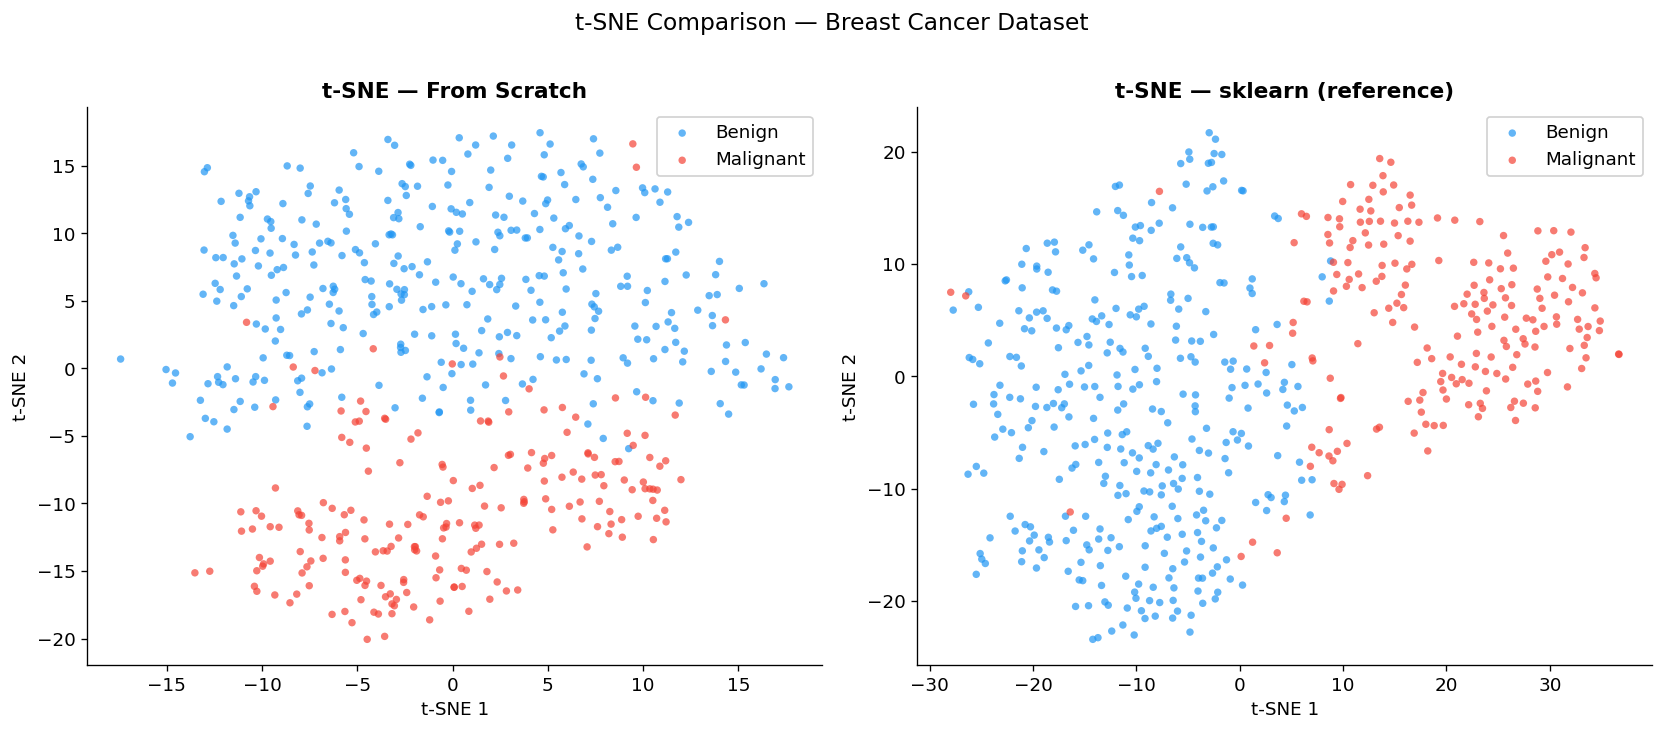

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

COLORS = {0: '#2196F3', 1: '#F44336'}
LABELS = {0: 'Benign', 1: 'Malignant'}

for ax, Y, title in zip(
    axes,
    [Y_scratch, Y_sklearn],
    ['t-SNE — From Scratch', 't-SNE — sklearn (reference)']
):
    for cls in [0, 1]:
        mask = y_all == cls
        ax.scatter(
            Y[mask, 0], Y[mask, 1],
            c=COLORS[cls], label=LABELS[cls],
            alpha=0.7, s=20, edgecolors='none'
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(framealpha=0.9)

plt.suptitle('t-SNE Comparison — Breast Cancer Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('tsne_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

---
## §7 — Results & Notes

### What the Plot Shows

Both implementations recover the same structure:
- **Two well-separated clusters** — benign and malignant are linearly separable in the embedding
- **Boundary overlap** — some ambiguous cases appear in both, reflecting true ambiguity in the 30D space
- **Different orientation** — t-SNE has no canonical axes; rotation is arbitrary

### Implementation vs sklearn

| Property | From Scratch | sklearn |
|---|---|---|
| Gradient | Exact O(n²) | Barnes-Hut O(n log n) |
| Early exaggeration factor | 4.0 | 12.0 |
| Speed on 569 points | ~2–5 min | < 5 sec |
| Cluster quality | Good | Tighter (due to higher exaggeration) |

### Critical Reminders When Interpreting t-SNE

> ⚠️ **Distances between clusters are NOT meaningful** — far apart does not mean unrelated  
> ⚠️ **Cluster sizes are NOT meaningful** — a large blob and small blob may have equal variance in high-D  
> ⚠️ **Not deterministic** — different seeds give different layouts  
> ⚠️ **Does not generalize** — cannot embed new points without rerunning  
> ⚠️ **Perplexity changes the picture** — always run multiple values before drawing conclusions